In [45]:
from dustmaps.config import config
import dustmaps.edenhofer2023
import healpy as hp
import astropy as ap

# 1. Set the data directory. 
# Creating a 'dustmaps_data' folder inside your current project directory keeps it local.
config['data_dir'] = './dustmaps_data'

# 2. Download the actual Edenhofer et al. (2023) dataset
# Warning: This is a large file and will take a few minutes to download!
dustmaps.edenhofer2023.fetch()

Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.


In [ ]:
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


In [ ]:
with fits.open("mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_dust_data_along_galactic_center = hdul["MEAN"].data[:, galactic_center_healpix];
    healpix_size = hdul["MEAN"].data[0, :].size
    distance_data = hdul['RADIAL PIXEL CENTERS'].data.field(0);
    distance_boundaries = hdul['RADIAL PIXEL BOUNDARIES'].data.field(0);
    #print(distance_boundaries)
    distance_gaps = np.diff(distance_boundaries)
    integrated_dust = np.dot(distance_gaps, hdul["MEAN"].data)


Filename: mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   


NEST
NEST
[  68.61873    69.00557    69.39459    69.785805   70.17923    70.57487
   70.97274    71.37285    71.77522    72.179855   72.58678    72.99599
   73.40751    73.82135    74.23752    74.65604    75.07692    75.50017
   75.925804   76.35384    76.78429    77.21716    77.65248    78.090256
   78.530495   78.97321    79.41843    79.86616    80.31641    80.769196
   81.22453    81.68244    82.14293    82.60602    83.07172    83.54004
   84.011      84.48462    84.9609     85.43987    85.92155    86.40594
   86.89305    87.38292    87.87555    88.37095    88.86915    89.37015
   89.87398    90.38065    90.890175   91.40257    91.91786    92.43606
   92.95717    93.481224   94.008224   94.53821    95.07117    95.60714
   96.14613    96.68816    97.233246   97.7814     98.33265    98.88701
   99.44449   100.00511   100.5689    101.135864  101.706024  102.279396
  102.856     103.43586   104.01898   104.6054    105.19512   105.78816
  106.38455   106.9843    107.58743   108.19396   1

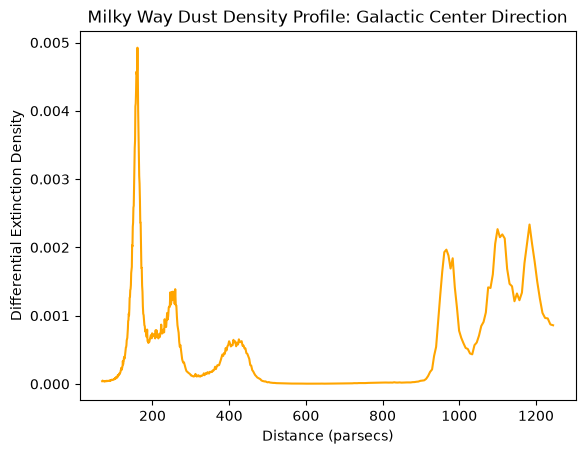

In [30]:
plt.plot(distance_data, mean_dust_data_along_galactic_center, label = "dust density along line through galactic center", alpha = 1, color = "orange")
plt.title("Milky Way Dust Density Profile: Galactic Center Direction")
plt.xlabel("Distance (parsecs)")
plt.ylabel("Differential Extinction Density")
plt.show();

<Figure size 1000x600 with 0 Axes>

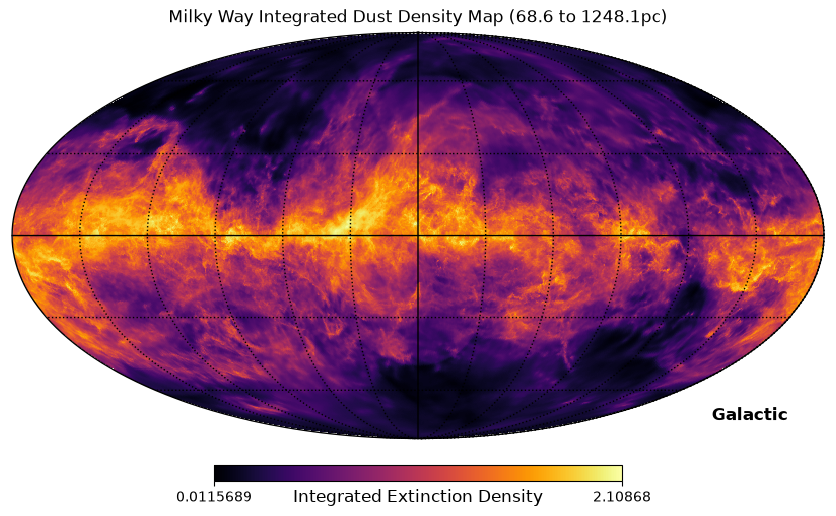

In [44]:
# 1. Set up a Matplotlib figure size
plt.figure(figsize=(10, 6))

# 2. Plot the mollview projection with log scaling to see faint details
hp.mollview(
    integrated_dust,  # 1D array of 786432 pixels
    nest=True,                  # Matches your map's NESTED format
    coord=["G"],                # Tells it the data is in Galactic coordinates
    title="Milky Way Integrated Dust Density Map (68.6 to 1248.1pc)",
    cmap="inferno",             # Beautiful dark-to-bright palette
    norm="log",                 # Log scale prevents disk from washing out poles
    unit="Integrated Extinction Density"
)

# 3. Superimpose a coordinate grid (latitude/longitude lines)
hp.graticule()

# 4. Display the finished masterpiece
plt.show()